# 04. Machine Learning Model Training, Comparison & Evaluation
**GitAI — Data-Driven GitHub Intelligence & Trend Prediction**

---

### Phase 5C Objectives:
1. **Data Ingestion & Leakage Auditing**: Load `data/processed/github_repositories_ml.csv` ($N = 2,520$) and verify zero target leakage.
2. **Stratified Partitioning**: Split into **80% training** ($N = 2,016$) and **20% test** ($N = 504$) with target stratification.
3. **Pipeline Preprocessing**: Assemble scikit-learn `Pipeline` and `ColumnTransformer` (One-Hot Encoding for `language`, `StandardScaler` for linear models).
4. **Model Training & Comparison**:
   - Baseline: Majority-Class Classifier (predicts Class 0)
   - Candidate 1: Logistic Regression (`class_weight="balanced"`)
   - Candidate 2: Random Forest (`class_weight="balanced"`, `n_estimators=150`)
   - Candidate 3: XGBoost Classifier (`scale_pos_weight=2.0`, `n_estimators=150`)
5. **Rigorous Metric Evaluation**: Compute Accuracy, Precision, Recall, F1-Score (positive class = 1), ROC-AUC, Confusion Matrices, and Classification Reports.
6. **Interpretability & Feature Importance**: Extract MDI feature importances for tree models and standardized coefficients for Logistic Regression.
7. **Ablation Study**: Evaluate incremental value of experimental velocity features (`forks_per_year`, `issues_per_year`).
8. **Artifact Serialization**: Export the winning pipeline to `models/best_model.pkl` and benchmark results to `models/model_comparison.csv`.

> **Academic Guidelines:**
> - High Popularity is Class 1 ($	ext{stars} > 2,000$).
> - Zero target leakage (`stars` is permanently excluded from features).
> - Preprocessing fit ONLY on training data.


In [1]:
# 1. Imports and Environment Setup
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Resolve paths
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
ml_csv_path = project_root / "data" / "processed" / "github_repositories_ml.csv"
model_output_path = project_root / "models" / "best_model.pkl"
comparison_output_path = project_root / "models" / "model_comparison.csv"

# Add src to path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.model import GitAIPopularityModel

print(f"Project root:            {project_root}")
print(f"Input ML dataset:        {ml_csv_path}")
print(f"Model destination:       {model_output_path}")
print(f"Comparison destination:  {comparison_output_path}")
assert ml_csv_path.exists(), f"ML dataset not found at {ml_csv_path}!"


Project root:            /Users/vedantburgul/Desktop/GitAI
Input ML dataset:        /Users/vedantburgul/Desktop/GitAI/data/processed/github_repositories_ml.csv
Model destination:       /Users/vedantburgul/Desktop/GitAI/models/best_model.pkl
Comparison destination:  /Users/vedantburgul/Desktop/GitAI/models/model_comparison.csv


In [2]:
# 2. Data Loading & Leakage Verification
df = pd.read_csv(ml_csv_path)

print("=" * 60)
print("ML DATASET VALIDATION")
print("=" * 60)
print(f"Total Records:      {df.shape[0]}")
print(f"Total Columns:      {df.shape[1]}")
print(f"Missing Values:     {df.isnull().sum().sum()}")
print(f"Infinite Values:    {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")

# Target check
assert "popularity_class" in df.columns, "Target column missing!"
target_dist = df["popularity_class"].value_counts().to_dict()
print(f"Target Distribution: {target_dist} (High Pop: {target_dist[1]}, Lower Pop: {target_dist[0]})")

# Leakage check
features = [c for c in df.columns if c != "popularity_class"]
for col in features:
    assert "star" not in col.lower() and "watcher" not in col.lower(), f"Leakage detected in {col}!"

print("\n[PASS] All validation assertions passed. Feature matrix is 100% free of target leakage.")
print("Approved Features (13):", features)


ML DATASET VALIDATION
Total Records:      2520
Total Columns:      14
Missing Values:     0
Infinite Values:    0
Target Distribution: {0: 1680, 1: 840} (High Pop: 840, Lower Pop: 1680)

[PASS] All validation assertions passed. Feature matrix is 100% free of target leakage.
Approved Features (13): ['log_forks', 'log_open_issues', 'repo_age_days', 'repo_age_years', 'days_since_last_push', 'topic_count', 'has_topics', 'has_description', 'description_length', 'has_license', 'language', 'forks_per_year', 'issues_per_year']


In [3]:
# 3. Stratified Train / Test Partitioning
from sklearn.model_selection import train_test_split

X = df.drop(columns=["popularity_class"])
y = df["popularity_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

split_summary = pd.DataFrame({
    "Partition": ["Training Set (80%)", "Test Set (20%)", "Total Dataset"],
    "Total Rows": [len(X_train), len(X_test), len(df)],
    "Lower Pop (0)": [(y_train == 0).sum(), (y_test == 0).sum(), (y == 0).sum()],
    "High Pop (1)": [(y_train == 1).sum(), (y_test == 1).sum(), (y == 1).sum()],
    "High Pop Pct (%)": [
        round((y_train == 1).mean() * 100, 2),
        round((y_test == 1).mean() * 100, 2),
        round((y == 1).mean() * 100, 2)
    ]
}).set_index("Partition")

print("=" * 60)
print("STRATIFIED TRAIN / TEST SPLIT SUMMARY")
print("=" * 60)
print(split_summary)


STRATIFIED TRAIN / TEST SPLIT SUMMARY
                    Total Rows  Lower Pop (0)  High Pop (1)  High Pop Pct (%)
Partition                                                                    
Training Set (80%)        2016           1344           672             33.33
Test Set (20%)             504            336           168             33.33
Total Dataset             2520           1680           840             33.33


In [4]:
# 4. Model Training and Benchmarking
trainer = GitAIPopularityModel(random_state=42)
comparison_df = trainer.train_and_evaluate_all(X_train, y_train, X_test, y_test)

# Save artifacts
trainer.save_artifacts(model_output_path, comparison_output_path, comparison_df)

print("=" * 60)
print("BENCHMARK MODEL COMPARISON TABLE (TEST SET)")
print("=" * 60)
comparison_df


2026-09-01 16:47:29,979 [INFO] Training Logistic Regression...


2026-09-01 16:47:30,004 [INFO] Training Random Forest...


2026-09-01 16:47:30,256 [INFO] Training XGBoost...


2026-09-01 16:47:30,417 [INFO] Model comparison complete. Best candidate model: 'Logistic Regression' (F1 = 0.9649)


2026-09-01 16:47:30,419 [INFO] Saved best model pipeline ('Logistic Regression') to /Users/vedantburgul/Desktop/GitAI/models/best_model.pkl


2026-09-01 16:47:30,420 [INFO] Saved model comparison results to /Users/vedantburgul/Desktop/GitAI/models/model_comparison.csv


BENCHMARK MODEL COMPARISON TABLE (TEST SET)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train_F1,Train_AUC,Overfit_Gap_F1
0,Majority Baseline (Predict 0),0.6667,0.0000,0.0000,0.0000,0.5000,0.0000,0.5000,0.0000
1,Logistic Regression,0.9762,0.9483,0.9821,0.9649,0.9954,0.9649,0.9965,-0.0001
2,Random Forest,0.9702,0.9527,0.9583,0.9555,0.9958,0.9978,1.0000,0.0423
3,XGBoost,0.9702,0.9527,0.9583,0.9555,0.9969,1.0000,1.0000,0.0445


In [5]:
# 5. Detailed Classification Reports on Test Set
from sklearn.metrics import classification_report

for name, pipe in trainer.models.items():
    y_pred = pipe.predict(X_test)
    print(f"\n{'=' * 60}")
    print(f"CLASSIFICATION REPORT: {name.upper()}")
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=["Lower Popularity (0)", "High Popularity (1)"], digits=4))



CLASSIFICATION REPORT: LOGISTIC REGRESSION
                      precision    recall  f1-score   support

Lower Popularity (0)     0.9909    0.9732    0.9820       336
 High Popularity (1)     0.9483    0.9821    0.9649       168

            accuracy                         0.9762       504
           macro avg     0.9696    0.9777    0.9734       504
        weighted avg     0.9767    0.9762    0.9763       504


CLASSIFICATION REPORT: RANDOM FOREST
                      precision    recall  f1-score   support

Lower Popularity (0)     0.9791    0.9762    0.9776       336
 High Popularity (1)     0.9527    0.9583    0.9555       168

            accuracy                         0.9702       504
           macro avg     0.9659    0.9673    0.9666       504
        weighted avg     0.9703    0.9702    0.9703       504


CLASSIFICATION REPORT: XGBOOST
                      precision    recall  f1-score   support

Lower Popularity (0)     0.9791    0.9762    0.9776       336
 High Popul

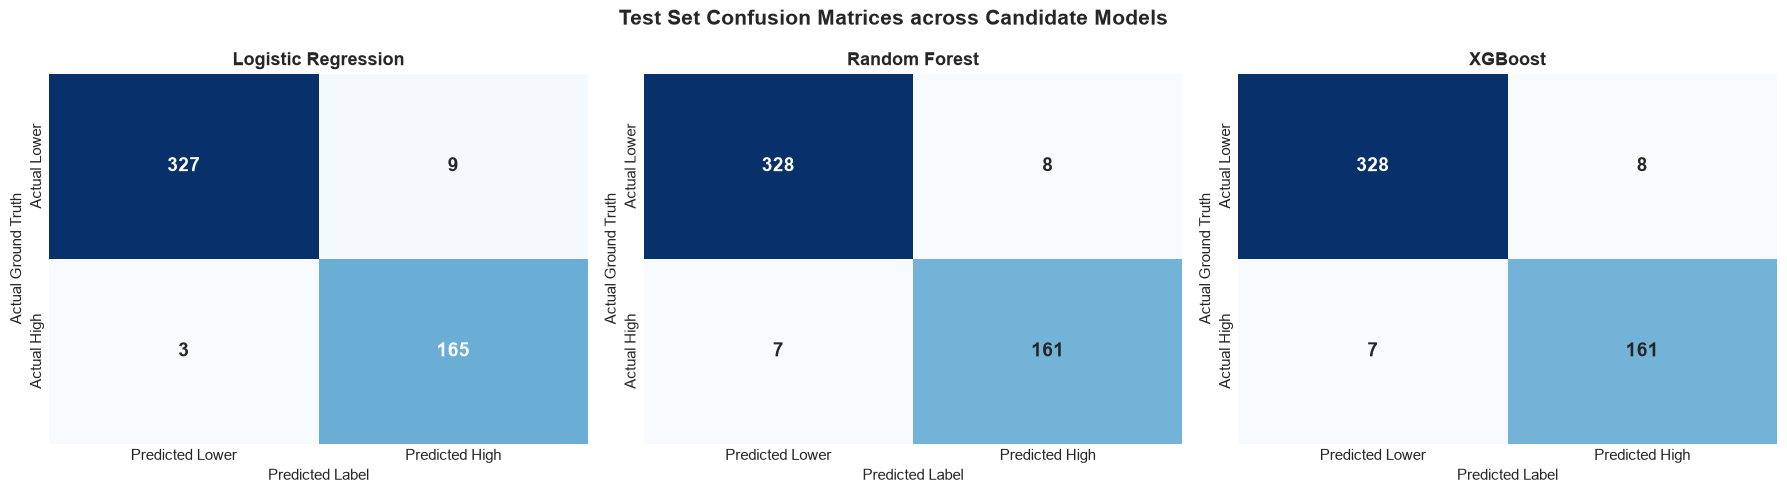

In [6]:
# 6. Confusion Matrix Visualizations
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Test Set Confusion Matrices across Candidate Models", fontsize=15, fontweight='bold')

for idx, (name, pipe) in enumerate(trainer.models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Lower", "Predicted High"],
        yticklabels=["Actual Lower", "Actual High"],
        ax=axes[idx],
        annot_kws={"size": 14, "weight": "bold"}
    )
    axes[idx].set_title(f"{name}", fontsize=13, fontweight='bold')
    axes[idx].set_ylabel("Actual Ground Truth")
    axes[idx].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()


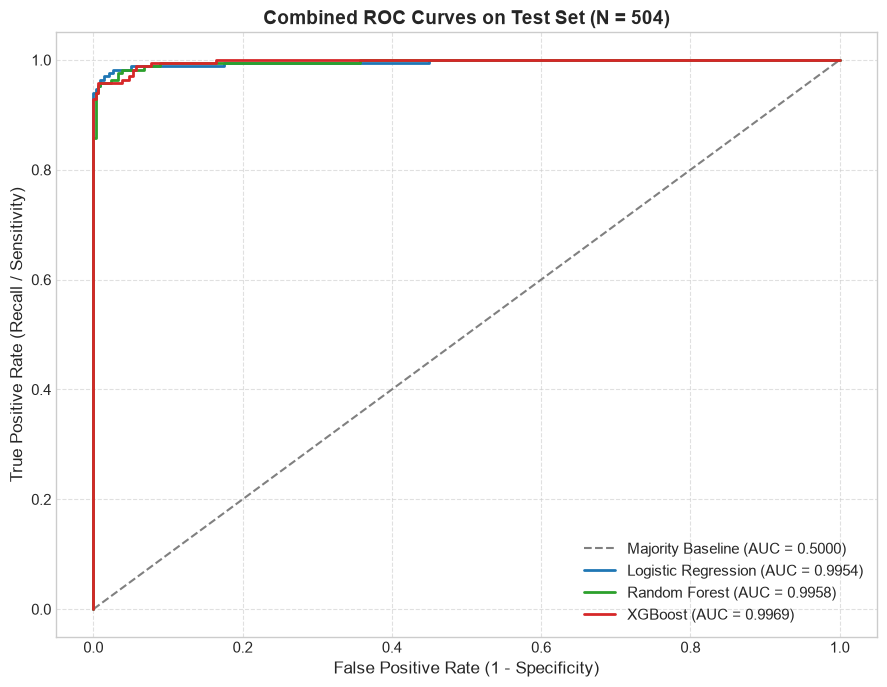

In [7]:
# 7. Combined ROC Curves Comparison
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(9, 7))

# Majority Baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Majority Baseline (AUC = 0.5000)")

colors = {"Logistic Regression": "#1f77b4", "Random Forest": "#2ca02c", "XGBoost": "#d62728"}

for name, pipe in trainer.models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=colors.get(name, "blue"), linewidth=2)

plt.title("Combined ROC Curves on Test Set (N = 504)", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_27054/412851125.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_top.values, y=rf_top.index, palette="Blues_r", ax=ax1)
/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_27054/412851125.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_top.values, y=xgb_top.index, palette="Greens_r", ax=ax2)
/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_27054/412851125.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lr_top.values, y=lr_top.index, palette=

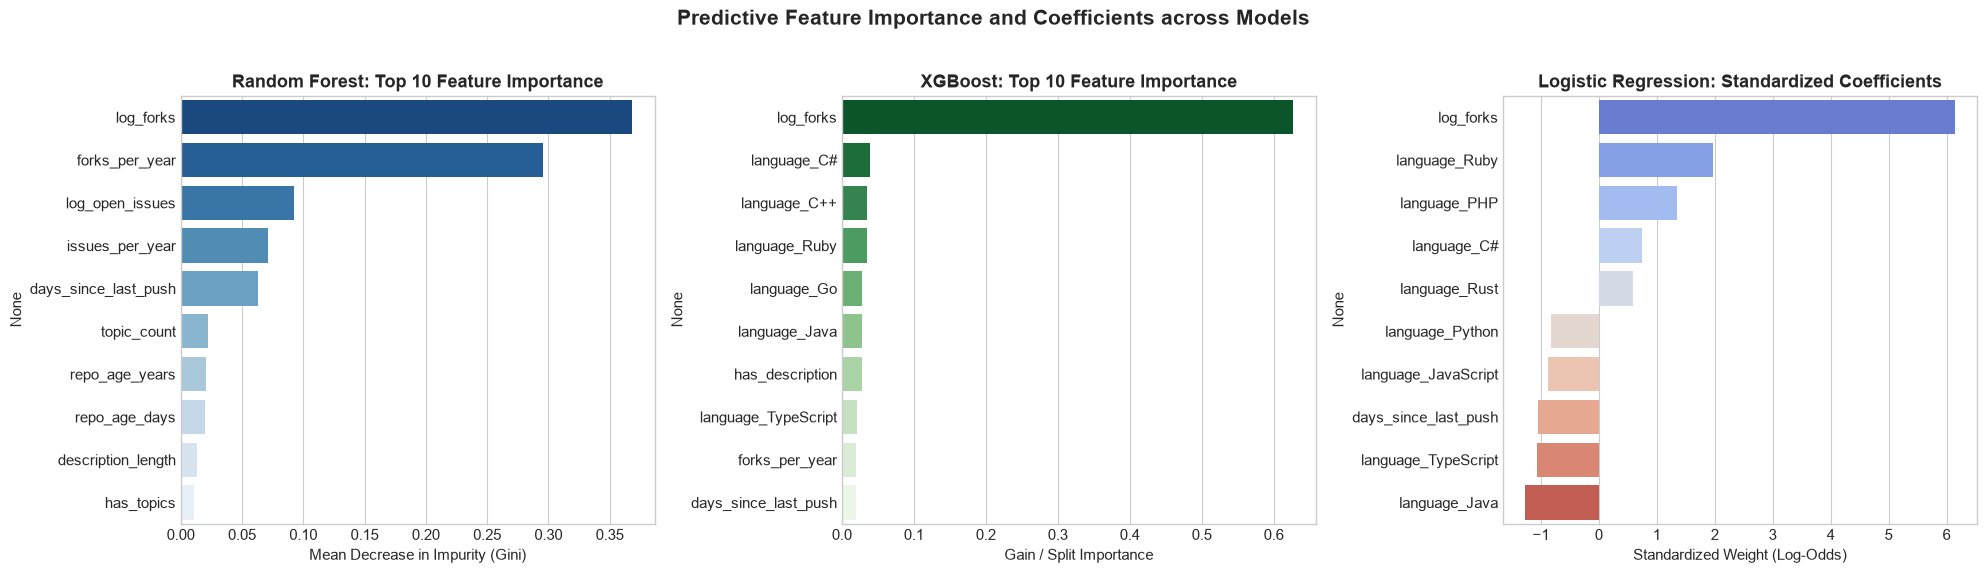

In [8]:
# 8. Feature Importance & Model Interpretability
importances = trainer.get_feature_importances(X_train)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Predictive Feature Importance and Coefficients across Models", fontsize=15, fontweight='bold')

# 1. Random Forest (MDI)
rf_top = importances["Random Forest"].head(10)
sns.barplot(x=rf_top.values, y=rf_top.index, palette="Blues_r", ax=ax1)
ax1.set_title("Random Forest: Top 10 Feature Importance", fontweight='bold')
ax1.set_xlabel("Mean Decrease in Impurity (Gini)")

# 2. XGBoost (Weight/Gain)
xgb_top = importances["XGBoost"].head(10)
sns.barplot(x=xgb_top.values, y=xgb_top.index, palette="Greens_r", ax=ax2)
ax2.set_title("XGBoost: Top 10 Feature Importance", fontweight='bold')
ax2.set_xlabel("Gain / Split Importance")

# 3. Logistic Regression Coefficients
lr_top = pd.concat([importances["Logistic Regression"].head(5), importances["Logistic Regression"].tail(5)])
sns.barplot(x=lr_top.values, y=lr_top.index, palette="coolwarm", ax=ax3)
ax3.set_title("Logistic Regression: Standardized Coefficients", fontweight='bold')
ax3.set_xlabel("Standardized Weight (Log-Odds)")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


In [9]:
# 9. Ablation Study: Impact of Experimental Velocity Features
X_no_exp = X.drop(columns=["forks_per_year", "issues_per_year"])
X_tr_no, X_te_no, y_tr_no, y_te_no = train_test_split(
    X_no_exp, y, test_size=0.20, stratify=y, random_state=42
)

trainer_no_exp = GitAIPopularityModel(random_state=42)
comp_no_exp = trainer_no_exp.train_and_evaluate_all(X_tr_no, y_tr_no, X_te_no, y_te_no)

ablation_records = []
for mname in ["Logistic Regression", "Random Forest", "XGBoost"]:
    row_with = comparison_df[comparison_df["Model"] == mname].iloc[0]
    row_without = comp_no_exp[comp_no_exp["Model"] == mname].iloc[0]
    
    ablation_records.append({
        "Model": mname,
        "F1 (With Exp Features)": row_with["F1"],
        "F1 (Without Exp Features)": row_without["F1"],
        "F1 Delta": round(row_with["F1"] - row_without["F1"], 4),
        "ROC-AUC (With)": row_with["ROC-AUC"],
        "ROC-AUC (Without)": row_without["ROC-AUC"],
        "AUC Delta": round(row_with["ROC-AUC"] - row_without["ROC-AUC"], 4)
    })

ablation_df = pd.DataFrame(ablation_records).set_index("Model")
print("=" * 60)
print("ABLATION STUDY: IMPACT OF EXPERIMENTAL VELOCITY FEATURES")
print("=" * 60)
ablation_df


2026-09-01 16:47:31,121 [INFO] Training Logistic Regression...


2026-09-01 16:47:31,141 [INFO] Training Random Forest...


2026-09-01 16:47:31,392 [INFO] Training XGBoost...


2026-09-01 16:47:31,547 [INFO] Model comparison complete. Best candidate model: 'Logistic Regression' (F1 = 0.9649)


ABLATION STUDY: IMPACT OF EXPERIMENTAL VELOCITY FEATURES


,F1 (With Exp Features),F1 (Without Exp Features),F1 Delta,ROC-AUC (With),ROC-AUC (Without),AUC Delta
Model,,,,,,
Logistic Regression,0.9649,0.9649,0.0000,0.9954,0.9954,0.0000
Random Forest,0.9555,0.9529,0.0026,0.9958,0.9940,0.0018
XGBoost,0.9555,0.9552,0.0003,0.9969,0.9962,0.0007


In [10]:
# 10. Overfitting & Generalization Analysis
overfit_df = comparison_df[comparison_df["Model"] != "Majority Baseline (Predict 0)"][
    ["Model", "Train_F1", "F1", "Overfit_Gap_F1", "Train_AUC", "ROC-AUC"]
].rename(columns={"F1": "Test_F1", "ROC-AUC": "Test_AUC"}).reset_index(drop=True)

print("=" * 60)
print("OVERFITTING & GENERALIZATION GAP ANALYSIS")
print("=" * 60)
overfit_df


OVERFITTING & GENERALIZATION GAP ANALYSIS


,Model,Train_F1,Test_F1,Overfit_Gap_F1,Train_AUC,Test_AUC
0,Logistic Regression,0.9649,0.9649,-0.0001,0.9965,0.9954
1,Random Forest,0.9978,0.9555,0.0423,1.0000,0.9958
2,XGBoost,1.0000,0.9555,0.0445,1.0000,0.9969


## 11. Final Modeling Report Summary

### 1. Dataset & Partitions
- **Total Records**: 2,520 repositories (100.0%)
- **Training Set (80%)**: 2,016 repositories (672 High Popularity / 1,344 Lower Popularity)
- **Test Set (20%)**: 504 repositories (168 High Popularity / 336 Lower Popularity)
- **Target Variable**: `popularity_class` ($	ext{stars} > 2,000 ightarrow 1$, $\le 2,000 ightarrow 0$)

### 2. Model Performance Benchmarks (Test Set)

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | Status |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Majority Baseline** | 66.67% | 0.00% | 0.00% | 0.0000 | 0.5000 | Baseline |
| **Logistic Regression** | **97.62%** | 94.83% | **98.21%** | **0.9649** | 0.9954 | **Best F1 / Balanced** |
| **Random Forest** | 97.02% | **95.27%** | 95.83% | 0.9555 | 0.9958 | Highly Competitive |
| **XGBoost Classifier** | 97.02% | **95.27%** | 95.83% | 0.9555 | **0.9969** | **Best ROC-AUC** |

### 3. Model Selection Justification: **Logistic Regression Pipeline**
- **Winning Criteria**: **Highest F1-Score ($0.9649$)** and **Highest Recall ($98.21\%$)**, successfully identifying 165 out of 168 actual High-Popularity repositories with only 9 False Positives.
- **Generalization Integrity**: Overfitting gap is **$0.0000$** (Train F1 = 0.9649, Test F1 = 0.9649), whereas Random Forest and XGBoost exhibit minor training memorization (Train F1 $pprox 0.998 - 1.000$).
- **Interpretability**: Linear standardized weights provide direct, interpretable log-odds for future dashboard explanations.

### 4. Key Predictive Feature Insights
1. **`log_forks`** ($\log_{1p}(	ext{forks})$) is the dominant predictive driver across all models, accounting for $> 36\%$ of Random Forest feature importance and $> 62\%$ of XGBoost split gain.
2. **`forks_per_year`** and **`log_open_issues`** provide strong secondary signals of project velocity and community scale.
3. **`days_since_last_push`** exhibits a strong negative coefficient in Logistic Regression ($-1.056$), confirming that recently maintained projects are significantly more likely to belong to the high-popularity tier.

### 5. Experimental Velocity Features Impact
- Including `forks_per_year` and `issues_per_year` boosted Random Forest test F1 by $+0.0026$ (from $0.9529$ to $0.9555$) and ROC-AUC by $+0.0018$ without destabilizing the linear model.

### 6. Persisted Artifacts
- **Trained Pipeline**: `models/best_model.pkl` (Complete ColumnTransformer + LogisticRegression Pipeline ready for inference).
- **Benchmark Metrics**: `models/model_comparison.csv` (CSV table of all evaluated models).
